## Objectif 1 : 
1-	Une étude de la corrélation entre les variables climatiques et la consommation <b>électrique nationale</b> et régionale française. 
Est-elle significative ? Est-ce que certaines variables climatiques ont un impact plus ou moins important sur la consommation électrique.

### 0- Import des bibliothéques nécessaires et créations des dossiers

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import os
#Pour la connexion à l'API 
import json
import requests
import time
from io import BytesIO

In [2]:
#Afin de limiter l'affichage des messages d'avertissement
import warnings
from requests.packages.urllib3.exceptions import InsecureRequestWarning
warnings.filterwarnings('ignore', category=InsecureRequestWarning)
# Pour afficher plus de 50 lignes
pd.set_option('display.max_rows', 300) 

In [2]:
#Création des dossiers nécessaires
if not os.path.exists("Fichiers"):  
    os.mkdir("Fichiers")
if not os.path.exists("Stations"):  
    os.mkdir("Stations")
#Création des dossiers pour la région Grand Est :
if not os.path.exists("Stations/GE/Listes"):  
    os.mkdir("Stations/GE/Listes")
else : print ("Le chemin Stations de GE existe déjà")
if not os.path.exists("Stations/GE/Mesures"):  
    os.mkdir("Stations/GE/Mesures")
else : print ("Le chemin Stations de GE existe déjà")

In [3]:
#On scrappe les données sur https://www.regions-departements-france.fr/ afin d'obtenir les numéros de département
page_Departements =pd.read_html("https://www.regions-departements-france.fr/", header ="infer")
tableau_Region=page_Departements[3]
tableau_Region.to_csv('Fichiers/1_Departement_et_Region.csv', index=False)
#La corse a un format spécifique et accepte difficillement la conversion int, on supprime cette région car elle nous intéresse pas pour l'instant.
tableau_Region[tableau_Region.Région!='Corse'].to_csv('Fichiers/2_Departement_et_Region.csv', index=False)              

In [3]:
#On recupere les départements de la région Grand Est
tableau_region = pd.read_csv('Fichiers/2_Departement_et_Region.csv',dtype={'N°':int, 'Département':str, 'Région':str})
region_grand_est = tableau_region[tableau_region.Région=='Grand Est']
departement_GE= list(region_grand_est.iloc[:,0])

### 1- Connexion à l'API Climatologique de météo France pour récupérer la liste des stations de la régions Grand Est et des enregistrements sur une année: 


#### a-Fonction qui permet de récupéréer les données

In [ ]:
#Il est nécessaire de créer un compte sur le portail api de meteofrance afin de générer un id : https://portail-api.meteofrance.fr/
APPLICATION_ID = 'imon_id'
# url to obtain acces token
TOKEN_URL = "https://portail-api.meteofrance.fr/token"

class Client(object):

    def __init__(self):
        self.session = requests.Session()

    def request(self, method, url, **kwargs):
        # First request will always need to obtain a token first
        if 'Authorization' not in self.session.headers:
            self.obtain_token()

        # Optimistically attempt to dispatch reqest
        response = self.session.request(method, url, **kwargs)
        if self.token_has_expired(response):
            # We got an 'Access token expired' response => refresh token
            self.obtain_token()
            # Re-dispatch the request that previously failed
            response = self.session.request(method, url, **kwargs)
        return response

    def token_has_expired(self, response):
        status = response.status_code
        content_type = response.headers['Content-Type']
        repJson = response.text
        if status == 401 and 'application/json' in content_type:
            repJson = response.text
            if 'Invalid JWT token' in repJson['description']:
                return True
        return False

    def obtain_token(self):
        # Obtain new token
        data = {'grant_type': 'client_credentials'}
        headers = {'Authorization': 'Basic ' + APPLICATION_ID}
        access_token_response = requests.post(TOKEN_URL, data=data, verify=False, allow_redirects=False, headers=headers)
        token = access_token_response.json()['access_token']
        # Update session with fresh token
        self.session.headers.update({'Authorization': 'Bearer %s' % token})
        
    def recuperer_liste_stations_quotidiennes_GE(self):
        for numeroDepartement in departement_GE :
            response = self.request('GET', 'https://public-api.meteofrance.fr/public/DPClim/v1/liste-stations/quotidienne?id-departement='+str(numeroDepartement), verify=False)
            stations = json.loads(response.content)
            #On recupere que les stations ouvertes : 
            stationsOuvertes = [station for station in stations if station["posteOuvert"] is True and station["typePoste"]==2]
            filename='Stations/GE/Listes/'+str(numeroDepartement)+'.json'
            with open(filename, 'w') as file:
                json.dump(stationsOuvertes, file)
            #Nécessaire de mettre un temps d'attente, sinon le code peut retourner une erreur
            time.sleep(2)
            
    def recuperer_valeurs_quotidiennes_stations(self,date_debut,date_fin):
        #On récupere les fichiers json des départements de la région disponible :
        chemin_repertoire = 'Stations/GE/Listes/'
        region_stations = os.listdir(chemin_repertoire)
        region_stations.remove('.ipynb_checkpoints')
        #On récupere les fichiers de mesure qui sont déjà présents afin d'éviter de lancer à nouveau la requète : 
        liste_mesure_stations = os.listdir('Stations/GE/Mesures/')
        liste_mesure_stations.remove('.ipynb_checkpoints')
        liste_mesure_stations = [string.replace(".csv", "") for string in liste_mesure_stations]
        for departement_stations in region_stations :
            #On ouvre les fichiers de chaque département
            with open(chemin_repertoire+departement_stations,'r') as file :
                stations = json.load(file)
            #On parcourt les stations de chaque  département et on lance la commande : 
                for station in stations:
                    id_station = station.get("id")
                    #On vérifie préalablement que le fichier n'existe pas déjà avec le if, si ce n'est pas le cas, on lance la commande
                    if id_station not in liste_mesure_stations : 
                        try : 
                            response = self.request('GET', 'https://public-api.meteofrance.fr/public/DPClim/v1/commande-station/quotidienne?id-station='+id_station+'&date-deb-periode='+date_debut+'&date-fin-periode='+date_fin, verify=False)
                            response_json = json.loads(response.content)
                            # On récupère l'id de la commande (c'est une API asynchrone)
                            id_commande = response_json.get('elaboreProduitAvecDemandeResponse').get('return')
                            time.sleep(3)
                            #On récupère les données avec la commande de la station cible: 
                            fichier_recup =  self.request('GET', 'https://public-api.meteofrance.fr/public/DPClim/v1/commande/fichier?id-cmde='+id_commande,verify=False)
                            #print(fichier_recup.status_code)
                            filename='Stations/GE/Mesures/'+id_station +'.csv'
                            with open(filename, 'wb') as file:
                                file.write(fichier_recup.content)
                                print("Fichier pour station "+id_station+" créé")
                        except :
                        # Capturer des erreurs spécifiques comme ZeroDivisionError ou TypeError
                            print("Une erreur est apparue avec la station : "+id_station)
                            
def main():
    client = Client()
    # Issue a series of API requests an example. For use this test, you must first subscribe to the arome api with your application
    client.session.headers.update({'Accept': 'application/json'})
    client.recuperer_liste_stations_quotidiennes_GE()
    client.recuperer_valeurs_quotidiennes_stations(date_debut='2023-02-01T00:00:00Z',date_fin='2024-01-31T00:00:00Z')
    
if __name__ == '__main__':
    main()

#### b- Création du dataframe avec toutes les stations de la région Grand Est et enregistrement en local

In [6]:
#Fonction de conversion de object en float
def convert_colonne(colonne) : 
    return colonne.replace(',', '.', regex=True).astype(float)

def concatenation_stations(type_de_station) : 
    colonnes_a_convertir = ['RR', 'TN', 'TX','TM','TMNX','TAMPLI','TNTXM','ETPGRILLE']
    mesures_stations = os.listdir(type_de_station)
    mesures_stations.remove('.ipynb_checkpoints')
    mesures_toutes_stations = pd.DataFrame()
    for mesures_station in mesures_stations :
        station_test = pd.read_csv(type_de_station+mesures_station,sep=';')
        #Suppression des colonnes complétement vides : 
        station_test=station_test.dropna(axis=1,how='all')
        #Boucle de traitement et de jointure 
        if 'DATE' not in  mesures_toutes_stations.columns :
            #Boucle de conversion 
            for col in colonnes_a_convertir :
                station_test[col]=convert_colonne(station_test[col]) 
            numero_station = str(station_test.iloc[1,0]) 
            station_test=station_test.drop(columns='POSTE')
            station_test = station_test.rename(mapper=lambda x: numero_station+"_"+x if x!= 'DATE' else x, axis=1)
            mesures_toutes_stations = station_test
        else : 
            for col in colonnes_a_convertir :
                station_test[col]=convert_colonne(station_test[col])
            numero_station = str(station_test.iloc[1,0])
            station_test.head()
            station_test=station_test.drop(columns='POSTE')
            station_test = station_test.rename(mapper=lambda x: numero_station+"_"+x if x!= 'DATE' else x, axis=1)
            station_test=station_test.drop(columns='DATE')
            mesures_toutes_stations= pd.concat([mesures_toutes_stations, station_test], axis=1)
    return mesures_toutes_stations


In [255]:
mesures_toutes_stations = concatenation_stations("Stations/GE/Mesures/")
mesures_toutes_stations.to_csv("Stations/GE/Concatenation/stationsGE.csv", sep=";")

In [227]:
#Ouverture du fichier 
mesures_toutes_stations= pd.read_csv("Stations/GE/Concatenation/stationsGE.csv",sep=";")

#### c- Analyse des données récupérées : <br> 
Le code ci-dessous explore les enregistrements des stations récupérées, notamment les données manquantes

Text(0.5, 0, 'Nombre de NA ')

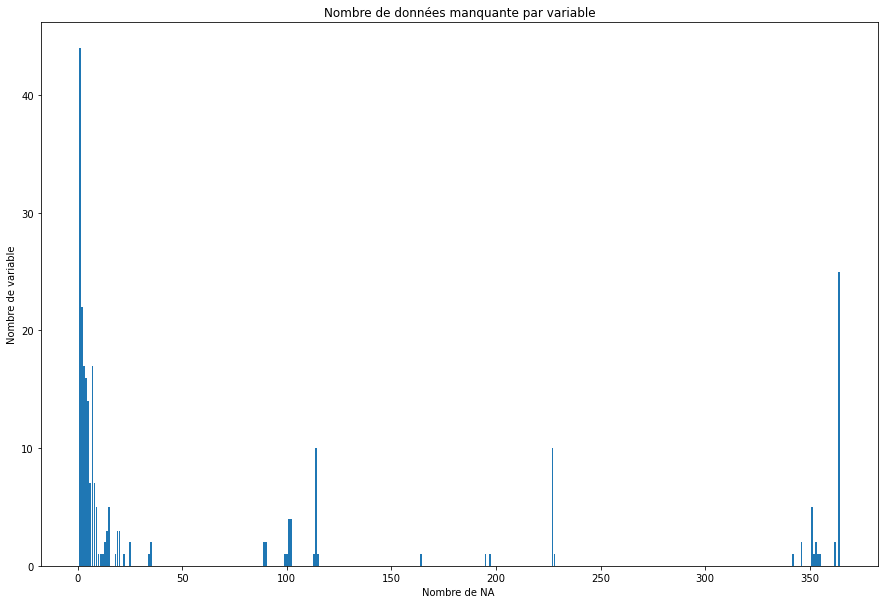

In [229]:
#Certaines données sont peu présentes dans le dataset 
DonneesVides= mesures_toutes_stations.isnull().sum()
DonneesVides[DonneesVides>0].count()
#226 colonnes contiennent des données vides. 
#On affiche les résultats de l'ensemble des valeurs du tavbleau : 
tab =DonneesVides[DonneesVides>0].value_counts()
plt.figure(figsize=(15, 10))
plt.bar(tab.index,tab.values)
plt.title("Nombre de données manquante par variable")
plt.ylabel("Nombre de variable")
plt.xlabel("Nombre de NA ")

In [ ]:
DonneesVides[DonneesVides>0].sort_values(ascending=False)

On remarque que certaines variables ont énormément de NA et une station dédiée comporte beaucoup de variable vides (60%)
Les variables avec beaucoup de NA de 25% à 99% de valeurs vides seront supprimés du dataset et la station avec beaucoup de valeurs vides (63% sur toutes les variables) écartée de l'analyse. 
Le reste des variables seront imputés. Les nouveaux fichiers seront enregistrés dans un dossier Mesures traitées avec un nettoyage des variables et une imputation <br> Certaines variables sont parfois uniques à un capteur en particulier ou sont peu présentes dans les stations. On retiendra surtout les variables suivantes : TNTXM, HTX, TM, TMNX, DG, TN, TAMPLI, RR, HTN, TX et ETPGRILLE qui sont communes à toutes les stations. 
La variable neige est seulement présente 25 fois, NEIGETOT06 et NEIGETOT0X 10 fois et 14 autres variables une seule fois. Ces variables ont pour la plupart du temps beaucoup de valeurs manquante
Pour la suite de l'étude, il a été décidé de les supprimer et de se concentrer sur les variables communes aux 109 capteurs , c'est à dire : 
#TNTXM         109
#HTX           109
#TM            109
#TMNX          109
#DG            109
#TN            109
#TAMPLI        109
#RR            109
#HTN           109
#TX            109
#ETPGRILLE     109

#### Signification des variables des stations : <br>
<b>RR</b> : Quantité de précipitation tombée en 24 heures.<br>
<b>TN </b>: Température minimale sous abri. <br>
<b>HTN </b>: Heure de TN (hhmm).<br>
<b>TX</b> : Température maximale sous abri. <br>
<b>HTX</b> : Heure de TX (hhmm). <br>
<b>TM</b> : Moyenne quotidienne des températures horaires sous abri. <br>
<b>TMNX</b> : Moyenne quotidienne (TN+TX)/2.  <br>
<b>DG</b> : Durée de gel sous abri. <br>
<b>TAMPLI</b> : Amplitude thermique quotidienne : Ecart entre TX et TN quotidiens (TX-TN). <br>
<b>TNTXM</b> : Moyenne quotidienne (TN+TX)/2 arrondie supérieur. <br>
<b>ETPGRILLE</b> :  EvapoTranspitration calculée au point de grille le plus proche (en millimetre) <br>
<b>NEIG</b> : Occurence de neige quotidienne : (0 si pas de neige et 1 si neige - phéno observé) <br>
<b>CONSOMMATION</b> : Consommation electrique en MW en GE. <br>
<b>Température sous abri</b> : La température sous abri est la température de l'air mesurée avec un thermomètre placé à 1,5 m du sol dans un abri ajouré. <br>
<b>Evapotranspiration</b> L’ETP est définie comme étant l’EvapoTranspiration d’un couvert végétal bas, continu et homogène, bien <br>

In [233]:
# On vérifie le nombre de variable peu présente dans le dataset afin de les supprimer ensuite: 
Variables = mesures_toutes_stations.columns.str.extract('_(.*)').value_counts()
# On récupère les variables qui ne sont pas communes à toutes les stations
VariablesIndex=Variables[Variables<109].index
# Convertir en tuple de chaînes
filtered_indices_tuple = tuple('_'.join(map(str, index_tuple)) for index_tuple in VariablesIndex)
filtered_indices_tuple 

('NEIG',
 'NEIGETOT06',
 'NEIGETOTX',
 'BROU',
 'TSVM',
 'ORAG',
 'HNEIGEF',
 'PMERMIN',
 'PMERM',
 'HUX',
 'HUN',
 'GRELE',
 'DHUMI80',
 'DHUMI40',
 'UM',
 'UN',
 'UX')

#### d- Imputation des données :

le code ci-dessous : 
- permet de supprimer les colonnes qui ont beaucoup de NA et ne sont pas communes à tous les capteurs;
- impute les données manquantes des colonnes gardées via l'algorithme des plus proches voisins
- sauvegarde les diagrammes de densité des valeurs imputées et non imputées afin de vérifier la méthode d'imputation utilisée.

A noter que cette méthode d'imputation ne sera pas utilisée par la suite car n'étant pas disponible sur Spark.

In [ ]:
# On importe fancyimpute
from fancyimpute import IterativeImputer, KNN

#Fonction de conversion de object en float
def convert_colonne(colonne) : 
    return colonne.replace(',', '.', regex=True).astype(float)
cheminchargement = "Stations/GE/Mesures/"
cheminchargementsauvegarde = "Stations/GE/Mesures_imputées/"
colonnes_a_convertir = ['RR', 'TN', 'TX','TM','TMNX','TAMPLI','TNTXM','ETPGRILLE']
mesures_stations = os.listdir(chemin_repertoire)
mesures_stations.remove('.ipynb_checkpoints')

for mesures_station in mesures_stations :
    mesures_toutes_stations = pd.DataFrame()
    fichier = pd.read_csv(chemin_repertoire+mesures_station,sep=';')
    # On supprime les colonnes entierement vides 
    fichier.dropna(axis=1,how='all',inplace=True)
    #Conversion des colonnes du fichier : 
    for col in colonnes_a_convertir :
                fichier[col]=convert_colonne(fichier[col])
    #print(fichier.dtypes)
    #On verifie qu'il n'y pas plus de valeur vide : 
    if (fichier.isna().sum().values.sum()==0) :
        fichier.to_csv(cheminchargementsauvegarde+mesures_station, sep=";",index=False)
        print("fichier traité et sauvegardé")
    else :
        #On supprime les colonnes en fonction du filtre et également si le nombre de valeur NA  
        for col in fichier.columns : 
            if col in filtered_indices_tuple : 
                fichier.drop(columns=col, inplace=True)

        #on vérifie à nouveau s'il y a des colonnes vides
        if (fichier.isna().sum().values.sum()>0) :
            #print(" je suis maintenant ici")
            colonnes_a_conserver = fichier[["POSTE","DATE"]]
          #On supprime les colonnes qui ne seront pas dans l'execution de l'imputation :
            colonne_a_imputer = fichier.drop(columns=["POSTE","DATE"])
          #On appelle la fonction d'imputation avec Fancyimpute et KNN: 
            knn_imputer = KNN()
            resultat = pd.DataFrame(knn_imputer.fit_transform(colonne_a_imputer), columns=colonne_a_imputer.columns)
          #On concaténe le fichier 
            concat = pd.concat([colonnes_a_conserver, resultat],axis=1)
            #print(concat.columns)
          #On récupère les colonnes qui sont vides dans le fichier initial afin de vérifier la densité entre colonne imputée ou non
            colonnes_avec_nan = fichier.columns[fichier.isnull().any()]
            liste_colonne= colonnes_avec_nan.values.tolist()
            for a in liste_colonne : 
                plt.figure()
                plt.title('Courbe de densité pour la variable '+ a + 'Station :'+mesures_station)
                sns.kdeplot(fichier[a], fill=True, color='blue', linewidth=2, label ="Variable "+a+" non imputée")
                sns.kdeplot(concat[a], fill=True, color='yellow', linewidth=2, label ="Variable "+a+" imputée")
                plt.legend()
                plt.savefig("Stations/GE/Densite/"+str(fichier.iloc[0,0])+"_"+a+".png")
            concat.to_csv(cheminchargementsauvegarde+mesures_station, sep=";", index=False)
        else :
            fichier.to_csv(cheminchargementsauvegarde+mesures_station, sep=";",index=False)

In [245]:
# Il semble que la station 57253001 a beaucoup de valeur manquante et il est difficle de l'imputer avec KNN
# Elle sera supprimée par la suite

Index(['Unnamed: 0', 'POSTE', 'DATE', 'RR', 'TN', 'HTN', 'TX', 'HTX', 'TM',
       'TMNX', 'DG', 'TAMPLI', 'TNTXM', 'ETPGRILLE'],
      dtype='object')

In [ ]:
#On concaténe le fichier avec les valeurs imputées et variables avec beaucoup de données manquantes supprimées : 
mesures_stations_imputees= concatenation_stations("Stations/GE/Mesures_imputées/")
# On sauvegarde ensuite le fichier imputé : 
mesures_stations_imputees.to_csv("Stations/GE/Concatenation/stationsGEimputees.csv",sep=";")

On verifie à nouveau les données manquantes, qui devrait être de 0

Text(0.5, 0, 'Nombre de NA ')

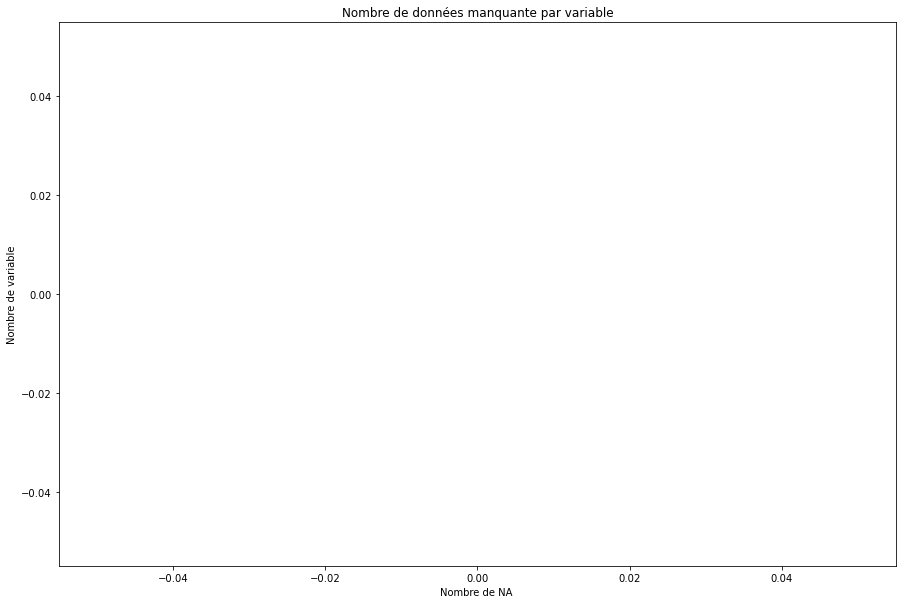

In [ ]:
#Certaines données sont peu présentes dans le dataset
mesures_stations_imputees = pd.read_csv("Stations/GE/Concatenation/stationsGEimputees.csv",sep=";")
DonneesVides= mesures_stations_imputees.isnull().sum()
DonneesVides[DonneesVides>0].count()
#226 colonnes contiennent des données vides. 
#On affiche les résultats de l'ensemble des valeurs du tableau : 
tab =DonneesVides[DonneesVides>0].value_counts()
plt.figure(figsize=(15, 10))
plt.bar(tab.index,tab.values)
plt.title("Nombre de données manquante par variable")
plt.ylabel("Nombre de variable")
plt.xlabel("Nombre de NA ")

In [ ]:
DonneesVides= mesures_stations_imputees.isnull().sum()
DonneesVides[DonneesVides!=0].count()
mesures_toutes_stations.isna().sum().to_csv("Stations/GE/Concatenation/sum.csv",sep=";")

A ce stade le dataframe mesures_station_imputee ne contient plus de valeurs vides

### 3- Récupération de la consommation electrique via l'API CONSOMMATION de ODRE

#### a- Code qui permet de récupérer les données :

In [238]:
#Récupération des données de l'API sur la consommation electrique ODRE : https://odre.opendatasoft.com/explore/dataset/eco2mix-regional-tr/table/?disjunctive.libelle_region&disjunctive.nature&sort=-date_heure
import requests
response = requests.get('https://odre.opendatasoft.com/api/explore/v2.1/catalog/datasets/eco2mix-regional-tr/records?select=sum(consommation)&where=code_insee_region%3D44%20AND%20(startswith(date%2C%20%222023%22)%20OR%20startswith(date%2C%20%222024-01%22))&group_by=date&order_by=date')
odre = json.loads(response.content)
odrepd= pd.DataFrame(odre['results'])
odrepd.drop(columns=['date'], inplace=True)
odrepd.columns
odrepd=odrepd.rename(columns={"sum(consommation)":"CONSOMMATION"})

In [259]:
mesures_stations_et_consommation= pd.concat([mesures_stations_imputees, odrepd], axis=1)

In [261]:
mesures_stations_et_consommation.to_csv("Stations/GE/Concatenation/stationsEtConsommationGE.csv",sep=";",index=False)

#### b- Analyse des données sur la consommation récupérées : 

<Figure size 432x288 with 0 Axes>

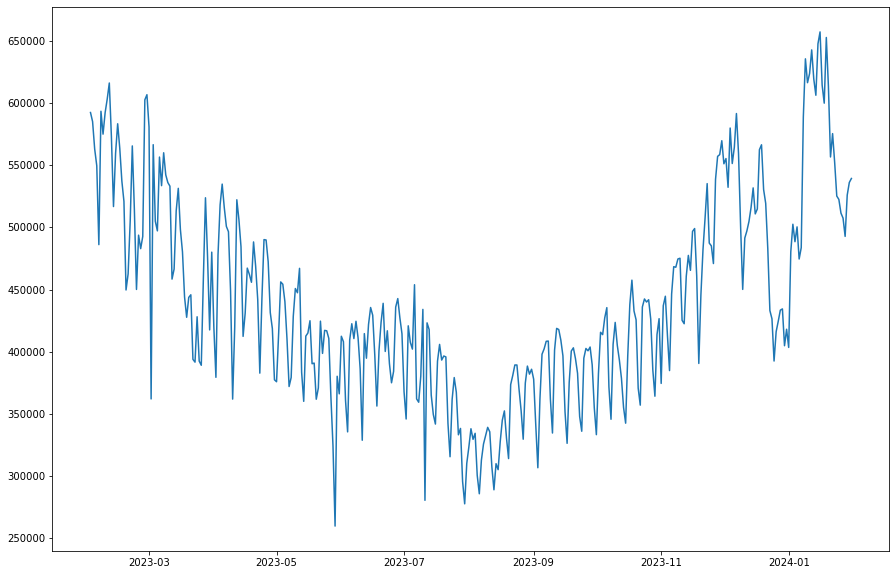

In [3]:
#Afficher la courbe de la consommation en fonction de la date de février 2023 à fin janvier 2024 :
import matplotlib.pyplot as plt
mesures_stations_et_consommation = pd.read_csv("Stations/GE/Concatenation/stationsEtConsommationGE.csv",sep=";")
if not os.path.exists("Statistiques"):  
    os.mkdir("Statistiques")
plt.tight_layout() 
plt.figure(figsize=(15, 10)) 
plt.plot(pd.to_datetime(mesures_stations_et_consommation["DATE"], format='%Y%m%d'), mesures_stations_et_consommation["CONSOMMATION"],)
#plt.plot(pd.to_datetime(mesures_toutes_stations["DATE"], format='%Y%m%d'), mesures_toutes_stations["8255001_TN"])
plt.savefig("Statistiques/1-consommation_annuelle_GE.png")

On remarque grâce à cette courbe : 
- que la consommation augmente en hivers et baisse en été. 
- Il y a des pics négatifs qui semblent assez réguliers, pouvant provenir d'un jours particulier (weekend, jour férié, autre ? ). <br>

On affiche ensuite la température moyenne des 109 stations en Grand Est sur la même période :

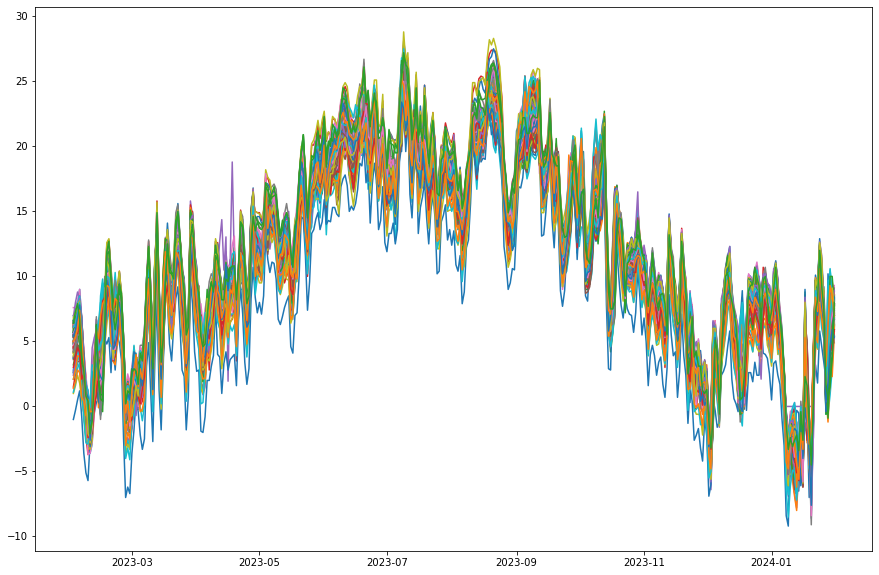

In [9]:
#plt.plot(pd.to_datetime(mesures_toutes_stations["DATE"], format='%Y%m%d'), mesures_toutes_stations["8255001_TM"])
selected_columns = mesures_stations_et_consommation[mesures_stations_et_consommation.columns[mesures_stations_et_consommation.columns.str.endswith('_TM')]]
plt.figure(figsize=(15, 10)) 
for i in selected_columns : 
    plt.plot(pd.to_datetime(mesures_stations_et_consommation["DATE"], format='%Y%m%d'), mesures_stations_et_consommation[i])
plt.savefig("Statistiques/2-Temperature moyenne toutes stations.png")

Rien qu'avec ces deux schémas, on peut en déduire qu'il y a une certaine corrélation entre la température moyenne journalière des capteurs et la consommation electrique. <br>
Le lien entre température et consommation semble plutôt négativement linéaire mais doit être confirmé.
En revanche, on peut apercevoir que les capteurs peuvent avoir un gros écart de température (parfois 15 degrés) <br> 

#### c- Code qui permet d'ajouter des variables en fonction de la date (saison, mois et jour)

In [137]:
mesures_stations_et_consommation = pd.read_csv('Stations/GE/Concatenation/stationsEtConsommationGE.csv',sep=";")

def saisons(mois):
    if mois in [12, 1, 2]:
        return 4
    elif mois in [9, 10, 11]:
        return 3
    elif mois in [6, 7, 8]:
        return 2
    elif mois in [3, 4, 5]:
        return 1
date = pd.to_datetime(mesures_stations_et_consommation["DATE"], format='%Y%m%d')
jour = date.dt.day_of_week
mois = date.dt.month
saisons = mois.apply(saisons)
mesures_stations_et_consommation.insert(1, 'JOUR', jour)
mesures_stations_et_consommation.insert(1, 'MOIS', mois)
mesures_stations_et_consommation.insert(1, 'SAISONS', saisons)
mesures_stations_et_consommation.to_csv('Stations/GE/Concatenation/stationsEtConsommationDateGE.csv',sep=";",index=False)

In [6]:
mesures_stations_et_consommation = pd.read_csv('Stations/GE/Concatenation/stationsEtConsommationDateGE.csv',sep=";")
mesures_stations_et_consommation.shape

(365, 1248)

### 4- Analyses des corrélations

#### a- Test de corrélation simple : 

In [7]:
import seaborn as sns

In [9]:
matrice = mesures_stations_et_consommation.corr()
matrice.to_csv("Statistiques/3-Test de corrélation.csv",sep=";")
matrice.shape
#https://datagy.io/python-correlation-matrix/

(1248, 1248)

#### b- Création de l'ACP 

In [13]:
# Import fonction ACP
from sklearn.decomposition import PCA
import numpy as np
# on standardise nos données : 
from sklearn.preprocessing import StandardScaler
values_cr = StandardScaler().fit_transform(mesures_stations_et_consommation.drop(columns=['CONSOMMATION']))

In [14]:
pca=PCA(2)
pca_wine = pca.fit_transform(values_cr)

In [15]:
pca.explained_variance_ratio_.sum()

0.6827180564778342

In [149]:
pca.get_precision()

array([[ 2.03394954e+00, -1.06830343e-02,  8.70838774e-03, ...,
         5.81218016e-04, -5.75846264e-04,  2.97256362e-03],
       [-1.06830343e-02,  2.02841424e+00, -2.04863208e-02, ...,
         1.12288676e-03,  1.28842381e-03,  1.79272824e-02],
       [ 8.70838774e-03, -2.04863208e-02,  2.02704883e+00, ...,
         4.94882040e-03,  9.38170638e-04,  1.52492572e-02],
       ...,
       [ 5.81218016e-04,  1.12288676e-03,  4.94882040e-03, ...,
         2.03666510e+00, -2.22114290e-04, -3.84098028e-03],
       [-5.75846264e-04,  1.28842381e-03,  9.38170638e-04, ...,
        -2.22114290e-04,  2.05462790e+00, -3.50875426e-03],
       [ 2.97256362e-03,  1.79272824e-02,  1.52492572e-02, ...,
        -3.84098028e-03, -3.50875426e-03,  2.03522687e+00]])

In [143]:
pca.get_covariance

<bound method _BasePCA.get_covariance of PCA(n_components=25)>

In [16]:

eig = pd.DataFrame(
    {
        "Dimension" : ["Dim" + str(x + 1) for x in range(2)], 
        "Variance expliquée" : pca.explained_variance_,
        "% variance expliquée" : np.round(pca.explained_variance_ratio_ * 100),
        "% cum. var. expliquée" : np.round(np.cumsum(pca.explained_variance_ratio_) * 100)
    }
)
eig

,Dimension,Variance expliquée,% variance expliquée,% cum. var. expliquée
0,Dim1,702.759423,56.0,56.0
1,Dim2,150.928865,12.0,68.0


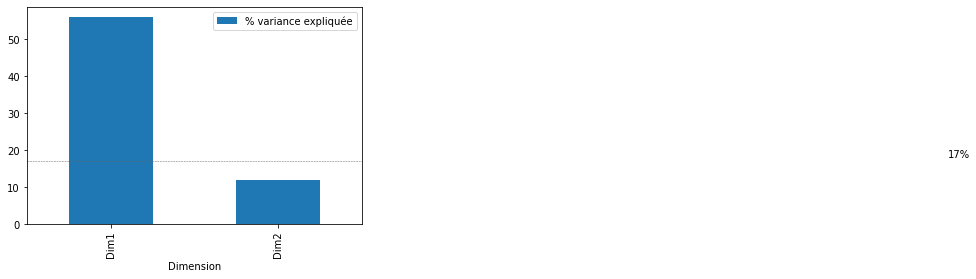

In [17]:
eig.plot.bar(x = "Dimension", y = "% variance expliquée") # permet un diagramme en barres
plt.text(5, 18) # ajout de texte
plt.axhline(y = 17, linewidth = .5, color = "dimgray", linestyle = "--") # ligne 17 = 100 / 6 (nb dimensions)
plt.show()

In [18]:
#Individus 
WGI_pca = pca.transform(values_cr)

In [96]:
variable_predictive_pca = pd.DataFrame(data=pca_wine, columns=['Dim1','Dim2',"Dim3","Dim4"])
variable_predictive_pca

,Dim1,Dim2,Dim3,Dim4
0,26.365007,8.942984,-11.811793,-1.452229
1,23.727149,9.677929,-11.830436,-0.719473
2,22.913933,11.448237,-11.222801,-0.548560
3,20.071172,11.218368,-9.886431,-0.468040
4,26.247843,8.906682,-8.398408,-2.049972
...,...,...,...,...
360,35.100397,-17.711165,3.557565,-0.390868
361,25.704117,-16.574572,3.270830,-6.448553
362,15.291096,-7.345429,-2.264650,-9.890904
363,16.489775,-1.923761,-6.157023,-6.721767


In [19]:
# Transformation en DataFrame pandas
WGI_pca_df = pd.DataFrame({
    "Dim1" : WGI_pca[:,0], 
    "Dim2" : WGI_pca[:,1],
})

# Résultat (premières lignes)
WGI_pca_df.head()

,Dim1,Dim2
0,26.365007,8.942984
1,23.727149,9.677929
2,22.913933,11.448237
3,20.071172,11.218368
4,26.247843,8.906682


l'analyse du cercle des corrélations et du graphe des individus a été réalisé sous R avec FactorMiner. Les raisons étant que cette bibliothèque est plus simple à utiliser et les données ne sont ici pas assez conséquente pour poser un problème avec cette bibliothèque. 

mesures_stations_et_consommation.drop(columns=['CONSOMMATION']).head()

plt.figure(figsize=(1, 790))
titi = matrice.iloc[:,1244]
titi = matrice.iloc[(titi < -0.5) | (toto > 0.5)]
sns.heatmap(titi, annot=True)
#plt.show()
#plt.savefig("Statistiques/3-Test de corrélation.png")

### 5- Test de création de plusieurs modèles

Cette partie a pour but de tester certains modèles sur les données journalières

In [ ]:
pip show sklearn

In [ ]:
pip list

In [20]:
pip show scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [12]:
pip install scikit-learn

     |████████████████████████████████| 11.1 MB 6.6 MB/s            
     |████████████████████████████████| 301 kB 70.3 MB/s            
Note: you may need to restart the kernel to use updated packages.


#### a- Test de création d'un modèle de Machine learning

Nous sommes sur de la régression, nous allons tester plusieurs méthodes. <br>
1- la régression ridge, GradientBoosting, RamdomForest et la régression linéaire : 

In [102]:
from sklearn.linear_model import Ridge, LinearRegression
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
from sklearn.metrics import explained_variance_score
from sklearn.metrics import median_absolute_error

y = mesures_stations_et_consommation["CONSOMMATION"]
x = WGI_pca_df

In [103]:
#On découpe le jeu de données
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.20)

In [104]:
modele_ridge = Ridge()
modele_ridge.fit(x_train,y_train)
y_predict_ridge = modele_ridge.predict(x_test)
print("RMCE:",np.sqrt(mean_squared_error(y_test,y_predict_ridge)))

RMCE: 42641.36212354862


Pour notre cas la moyenne des erreurs est de plus de 40000. Ce score est relativement élevé mais il peut s'expliquer à cause du peu de données disponible pour l'entrainement 

In [105]:
modelG = GradientBoostingRegressor(n_estimators=100, random_state=20,max_depth=3, learning_rate=0.02)
modelG.fit(x_train, y_train)
y_pred_GradientBoost = modelG.predict(x_test)
print("RMCE:",np.sqrt(mean_squared_error(y_test,y_pred_GradientBoost)))

RMCE: 44914.52689455887


In [106]:
rf_regressor = RandomForestRegressor(n_estimators=200, max_depth=None)
rf_regressor.fit(x_train, y_train)
y_pred_rf_regressor = rf_regressor.predict(x_test)

print("RMCE:",np.sqrt(mean_squared_error(y_test,y_pred_rf_regressor)))

RMCE: 47784.10965658832


In [107]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(x_train, y_train)
y_pred_linear = model.predict(x_test)
print("RMCE:",np.sqrt(mean_squared_error(y_test,y_pred_linear)))

RMCE: 42641.32626737334


#### b- Résultats

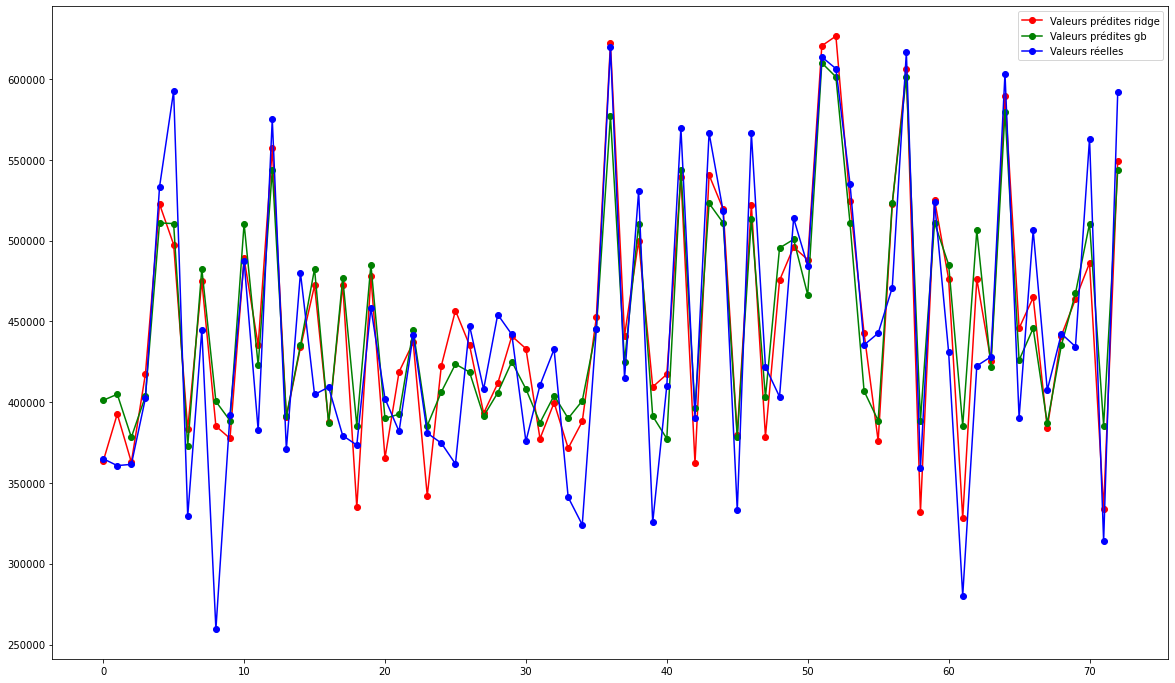

In [113]:
#On compare la prédiction réalisée à la consommation réelle en affichant directement les résultats : 
plt.figure(figsize=(20,12))
# Tracer les valeurs réelles
y_test_2 = y_test.reset_index(drop=True)
plt.plot(y_predict_ridge, label="Valeurs prédites ridge", color='red', marker='o')
plt.plot(y_pred_GradientBoost, label="Valeurs prédites gb", color='green', marker='o')
plt.plot(y_test.array, label="Valeurs réelles", color='blue', marker='o')
plt.legend()